# Cleaned and Functionalized Ephys Analysis Notebook
This notebook contains a functionalized and organized version of the original analysis, with reusable functions and clear structure for reproducible analysis and visualization.

In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import cm

# --- Data Loading Functions ---
def load_mat_file(mat_path):
    data = scipy.io.loadmat(mat_path, struct_as_record=False, squeeze_me=True)
    return data

def mat_struct_to_dict(obj):
    if isinstance(obj, np.ndarray):
        if obj.dtype == 'O':
            return [mat_struct_to_dict(o) for o in obj]
        else:
            return obj
    elif hasattr(obj, '_fieldnames'):
        return {field: mat_struct_to_dict(getattr(obj, field)) for field in obj._fieldnames}
    else:
        return obj

def get_session_dict(data_dict1):
    try:
        data_dict = mat_struct_to_dict(data_dict1['data'])
    except KeyError:
        data_dict = mat_struct_to_dict(data_dict1['ans'])
    return data_dict

def get_drilled_down(data_dict, session_key, subkey):
    return data_dict[session_key][subkey]

# --- Analysis Functions ---
def get_trials_and_outcomes(session):
    behav_data = session['behav_data']
    trials = behav_data['trials_data_exp']
    outcomes = np.array([trial['trialoutcome'] for trial in trials])
    return trials, outcomes

def get_event_times(ni_events, align_to, trials, outcomes, outcome_of_interest=None):
    n_trials = len(trials)
    if align_to in ni_events:
        event_arr = ni_events[align_to]
        if isinstance(event_arr, dict) and 'rise_t' in event_arr:
            event_times_all = np.array(event_arr['rise_t']).flatten()
        else:
            event_times_all = np.array(event_arr).flatten()
        if outcome_of_interest is not None:
            mask = outcomes == outcome_of_interest
            event_times = event_times_all[mask]
            trial_indices = np.where(mask)[0]
            trial_outcomes = outcomes[mask]
        else:
            event_times = event_times_all
            trial_indices = np.arange(n_trials)
            trial_outcomes = outcomes
        align_label = align_to
    elif align_to == 'trialoutcome_time':
        event_times_all = np.array([trial['hit_time'] for trial in trials])
        if outcome_of_interest is not None:
            mask = outcomes == outcome_of_interest
            event_times = event_times_all[mask]
            trial_indices = np.where(mask)[0]
            trial_outcomes = outcomes[mask]
        else:
            event_times = event_times_all
            trial_indices = np.arange(n_trials)
            trial_outcomes = outcomes
        align_label = 'Hit Time'
    else:
        raise ValueError(f"Unknown align_to: {align_to}")
    return event_times, trial_indices, align_label, trial_outcomes

# --- Visualization Functions ---
def plot_psth_raster_grid_sorted(session, align_to='Change_ON', outcome_of_interest='Hit', clusters_per_row=10, min_trials_with_spikes=20, save_figure=False):
    npx_probes = session['NPX_probes']
    ni_events = session['NI_events']
    trials, outcomes = get_trials_and_outcomes(session)
    spike_times = npx_probes['st']
    cluster_ids = npx_probes['clu']
    event_times, trial_indices, align_label, trial_outcomes = get_event_times(ni_events, align_to, trials, outcomes, outcome_of_interest)
    good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
    window = [-0.5, 1.0]
    bin_size = 0.05
    bins = np.arange(window[0], window[1] + bin_size, bin_size)
    window_length = window[1] - window[0]
    clusters_to_plot = []
    rasters_for_plot = []
    counts_for_plot = []
    mean_rates = []
    for clu in good_clusters:
        spike_times_clu = spike_times[cluster_ids == clu]
        all_counts = []
        all_rasters = []
        for t in event_times:
            aligned = spike_times_clu - t
            mask = (aligned >= window[0]) & (aligned <= window[1])
            all_rasters.append(aligned[mask])
            all_counts.append(np.histogram(aligned[mask], bins=bins)[0])
        n_trials_with_spikes = sum(len(ras) > 0 for ras in all_rasters)
        if n_trials_with_spikes > min_trials_with_spikes:
            clusters_to_plot.append(clu)
            rasters_for_plot.append(all_rasters)
            counts_for_plot.append(np.array(all_counts))
            mean_rate = np.sum(all_counts) / (len(all_counts) * window_length)
            mean_rates.append(mean_rate)
    if len(mean_rates) == 0:
        print("No clusters passed the spike-in-trials filter. Adjust your parameters.")
        return
    sort_idx = np.argsort(mean_rates)[::-1]
    clusters_to_plot = [clusters_to_plot[i] for i in sort_idx]
    rasters_for_plot = [rasters_for_plot[i] for i in sort_idx]
    counts_for_plot = [counts_for_plot[i] for i in sort_idx]
    mean_rates = [mean_rates[i] for i in sort_idx]
    n_plot = len(clusters_to_plot)
    n_cols = clusters_per_row * 2 + (clusters_per_row - 1)
    n_rows = int(np.ceil(n_plot / clusters_per_row))
    width_ratios = []
    for i in range(clusters_per_row):
        width_ratios.extend([1, 1])
        if i < clusters_per_row - 1:
            width_ratios.append(0.3)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 1.8 * n_rows), sharex='col', gridspec_kw={'width_ratios': width_ratios})
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    for idx, (clu, all_rasters, all_counts) in enumerate(zip(clusters_to_plot, rasters_for_plot, counts_for_plot)):
        row = idx // clusters_per_row
        col_pair = idx % clusters_per_row
        base_col = col_pair * 3
        ax_psth = axes[row, base_col]
        ax_raster = axes[row, base_col + 1]
        psth = np.mean(all_counts, axis=0) / bin_size if len(all_counts) > 0 else np.zeros(len(bins)-1)
        ax_psth.step(bins[:-1], psth, where='post', color='k')
        ax_psth.axvline(0, color='r', linestyle='--', lw=0.8)
        ax_psth.set_ylim(bottom=0)
        ax_psth.tick_params(axis='y', labelsize=7)
        ax_psth.text(0.98, 0.95, f'Clu {clu}', ha='right', va='top', fontsize=8, transform=ax_psth.transAxes,
                     bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.7))
        if row == n_rows - 1:
            xticks = [window[0], -0.5, 0, 0.5, window[1]]
            xticks = sorted(set([x for x in xticks if window[0] <= x <= window[1]]))
            ax_psth.set_xticks(xticks)
            ax_psth.set_xticklabels([f"{b:.2f}" for b in xticks], rotation=0, fontsize=9)
            ax_psth.set_xlabel(f'Time from {align_label} (s)')
        else:
            ax_psth.set_xticklabels([])
        if col_pair == 0:
            ax_psth.set_ylabel('Firing rate (Hz)')
        n_trials_raster = len(all_rasters)
        for trial, ras in enumerate(all_rasters):
            ax_raster.vlines(ras, trial + 0.5, trial + 1.5, color='k', lw=0.5)
        ax_raster.axvline(0, color='r', linestyle='--', lw=0.8)
        ax_raster.set_ylim(0.5, n_trials_raster + 0.5)
        if n_trials_raster >= 3:
            trial_ticks = [1, n_trials_raster // 2 + 1, n_trials_raster]
        else:
            trial_ticks = list(range(1, n_trials_raster + 1))
        ax_raster.set_yticks(trial_ticks)
        ax_raster.set_yticklabels([str(t) for t in trial_ticks], fontsize=7)
        ax_raster.invert_yaxis()
        ax_raster.text(0.98, 0.95, f'Clu {clu}', ha='right', va='top', fontsize=8, transform=ax_raster.transAxes,
                      bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.7))
        if row == n_rows - 1:
            ax_raster.set_xticks(xticks)
            ax_raster.set_xticklabels([f"{b:.2f}" for b in xticks], rotation=0, fontsize=9)
            ax_raster.set_xlabel(f'Time from {align_label} (s)')
        else:
            ax_raster.set_xticklabels([])
        if col_pair == clusters_per_row - 1:
            ax_raster.set_ylabel('Trial')
        if row == 0:
            ax_psth.set_title('PSTH')
            ax_raster.set_title('Raster')
    for row in range(n_rows):
        for i in range(clusters_per_row - 1):
            spacer_col = i * 3 + 2
            axes[row, spacer_col].axis('off')
    plt.tight_layout(h_pad=0.2, w_pad=0.05)
    if save_figure:
        output_dir = 'png_output'
        os.makedirs(output_dir, exist_ok=True)
        fig.savefig(os.path.join(output_dir, f'clusters_grid_sorted_Hz.png'), dpi=150)
        plt.close(fig)
    else:
        plt.show()

# --- Mean PSTH Comparison Function ---
def plot_mean_psth_comparison(session, align_to='Baseline_ON', outcomes_to_compare=['Miss','FA','Hit','abort'], min_trials_with_spikes=20, use_same_clusters=True):
    npx_probes = session['NPX_probes']
    ni_events = session['NI_events']
    trials, outcomes = get_trials_and_outcomes(session)
    spike_times = npx_probes['st']
    cluster_ids = npx_probes['clu']
    window = [-0.5, 1.0]
    bin_size = 0.02
    bins = np.arange(window[0], window[1] + bin_size, bin_size)
    good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
    all_psths_by_outcome = {outcome: {} for outcome in outcomes_to_compare}
    clusters_passing = {outcome: set() for outcome in outcomes_to_compare}
    for outcome_of_interest in outcomes_to_compare:
        event_times, trial_indices, align_label, _ = get_event_times(ni_events, align_to, trials, outcomes, outcome_of_interest)
        n_trials_this_outcome = len(event_times)
        for clu in good_clusters:
            spike_times_clu = spike_times[cluster_ids == clu]
            all_counts = []
            for t in event_times:
                aligned = spike_times_clu - t
                mask_spk = (aligned >= window[0]) & (aligned <= window[1])
                counts, _ = np.histogram(aligned[mask_spk], bins=bins)
                all_counts.append(counts)
            all_counts = np.array(all_counts)
            n_trials_with_spikes = np.sum(np.sum(all_counts, axis=1) > 0)
            if n_trials_with_spikes > min_trials_with_spikes:
                # Compute mean firing rate per bin (Hz): mean spike count per bin per trial, divided by bin size
                psth = np.mean(all_counts, axis=0) / bin_size if len(all_counts) > 0 else np.zeros(len(bins)-1)
                all_psths_by_outcome[outcome_of_interest][clu] = psth
                clusters_passing[outcome_of_interest].add(clu)
    if use_same_clusters:
        clusters_to_use = set.intersection(*[clusters_passing[o] for o in outcomes_to_compare])
    else:
        clusters_to_use = set.union(*[clusters_passing[o] for o in outcomes_to_compare])
    mean_psths = {}
    counts_per_outcome = {}
    for outcome in outcomes_to_compare:
        psths = [all_psths_by_outcome[outcome][clu] for clu in clusters_to_use if clu in all_psths_by_outcome[outcome]]
        psths = np.array(psths)
        mean_psths[outcome] = np.mean(psths, axis=0) if len(psths) > 0 else np.zeros(len(bins)-1)
        counts_per_outcome[outcome] = len(psths)
    # Additional: print mean firing rate for each outcome for debugging
    for outcome in outcomes_to_compare:
        mean_rate = np.mean(mean_psths[outcome])
        print(f"Mean firing rate for {outcome}: {mean_rate:.2f} Hz (n={counts_per_outcome[outcome]})")
    plt.figure(figsize=(8, 5))
    colors = ['b', 'r', 'g', 'm', 'c']
    for i, outcome in enumerate(outcomes_to_compare):
        plt.step(bins[:-1], mean_psths[outcome], where='post', label=f"{outcome} (n={counts_per_outcome[outcome]})", color=colors[i % len(colors)])
    plt.axvline(0, color='k', linestyle='--', lw=0.8)
    plt.xlabel(f'Time from {align_label} (s)')
    plt.ylabel('Firing rate (Hz)')
    plt.title(f'Mean PSTH for outcomes aligned to {align_label}\n(Clusters used: {len(clusters_to_use)})')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Heatmap Visualization Function ---
def plot_cluster_heatmap(session, align_to='Baseline_ON', outcome_of_interest='Hit', min_trials_with_spikes=20, normalize=True, save_figure=False):
    npx_probes = session['NPX_probes']
    ni_events = session['NI_events']
    trials, outcomes = get_trials_and_outcomes(session)
    spike_times = npx_probes['st']
    cluster_ids = npx_probes['clu']
    event_times, trial_indices, align_label, _ = get_event_times(ni_events, align_to, trials, outcomes, outcome_of_interest)
    good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
    window = [-0.5, 1.0]
    bin_size = 0.05
    bins = np.arange(window[0], window[1] + bin_size, bin_size)
    all_psths = []
    cluster_labels = []
    for clu in good_clusters:
        spike_times_clu = spike_times[cluster_ids == clu]
        all_counts = []
        for t in event_times:
            aligned = spike_times_clu - t
            mask = (aligned >= window[0]) & (aligned <= window[1])
            counts, _ = np.histogram(aligned[mask], bins=bins)
            all_counts.append(counts)
        all_counts = np.array(all_counts)
        n_trials_with_spikes = np.sum(np.sum(all_counts, axis=1) > 0)
        if n_trials_with_spikes > min_trials_with_spikes:
            # Convert to Hz: mean spike count per bin per trial, divided by bin size
            mean_psth = np.mean(all_counts, axis=0) / bin_size
            all_psths.append(mean_psth)
            cluster_labels.append(clu)
    if len(all_psths) == 0:
        print("No clusters passed the spike-in-trials filter.")
        return
    data = np.array(all_psths)
    if normalize:
        data = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)
        vmin, vmax = -2, 2
        cmap = 'bone'
    else:
        vmin, vmax = np.percentile(data, 1), np.percentile(data, 99)
        cmap = 'bone'
    peak_times = np.argmax(data, axis=1)
    sort_idx = np.argsort(peak_times)
    data = data[sort_idx]
    cluster_labels = np.array(cluster_labels)[sort_idx]
    plt.figure(figsize=(5, min(3, len(cluster_labels) * 0.15)))
    plt.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
               extent=[bins[0], bins[-1], 0, len(cluster_labels)])
    plt.colorbar(label='Firing rate (z-score)' if normalize else 'Firing rate (Hz)')
    plt.xlabel(f'Time from {align_label} (s)')
    plt.ylabel('Cluster')
    renumber_clusters = True
    yticks = np.linspace(0.5, len(cluster_labels)-0.5, min(5, len(cluster_labels)))
    if renumber_clusters:
        yticklabels = [str(int(i)+1) for i in np.linspace(len(cluster_labels)-1,0, len(yticks)).astype(int)]
        plt.ylabel('Cluster (renumbered)')
    else:
        yticklabels = [cluster_labels[int(i)] for i in np.linspace(0, len(cluster_labels)-1, len(yticks)).astype(int)]
        plt.ylabel('Cluster')
    plt.yticks(yticks, yticklabels)
    xticks = np.arange(bins[0], bins[-1] + 0.001, 0.25)
    if 0 not in xticks:
        xticks = np.sort(np.append(xticks, 0))
    xticks = np.unique(np.concatenate(([bins[0]], xticks, [bins[-1]])))
    xticks = np.round(xticks, 8)
    plt.xticks(xticks, [f"{x:.2f}" for x in xticks])
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f'heatmap around {align_to} for {outcome_of_interest}')
    plt.tight_layout()
    if save_figure:
        output_dir = 'png_output'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'{align_to}_{outcome_of_interest}_clusters_heatmap_sorted_peakHz.png'), dpi=150)
        plt.close()
    else:
        plt.show()



# --- PSTH Comparison Aligned to Reaction Time for Each Outcome ---
def get_true_reaction_time(trial, ni_events, trial_idx, shift_fa_hit_ms=200.0):
    outcome = trial['trialoutcome']
    reactiontimes = trial.get('reactiontimes', {})
    # Get Baseline_ON time
    if 'Baseline_ON' in ni_events:
        baseline_on = ni_events['Baseline_ON']
        if isinstance(baseline_on, dict) and 'rise_t' in baseline_on:
            baseline_on_times = np.array(baseline_on['rise_t']).flatten()
        else:
            baseline_on_times = np.array(baseline_on).flatten()
        t0 = baseline_on_times[trial_idx]
    else:
        return None
    # Get Change_ON time (if available)
    if 'Change_ON' in ni_events:
        change_on = ni_events['Change_ON']
        if isinstance(change_on, dict) and 'rise_t' in change_on:
            change_on_times = np.array(change_on['rise_t']).flatten()
        else:
            change_on_times = np.array(change_on).flatten()
        t_change = change_on_times[trial_idx] if trial_idx < len(change_on_times) else None
    else:
        t_change = None
    # Compute true reaction time
    shift = 0.0
    if outcome in ['FA', 'Hit']:
        shift = shift_fa_hit_ms / 1000.0  # convert ms to s
    if outcome == 'Hit':
        rt = reactiontimes.get('RT', np.nan)
        if not np.isnan(rt) and t_change is not None:
            return t_change + rt - shift
        else:
            return None
    elif outcome == 'Miss':
        rt = reactiontimes.get('Miss', np.nan)
        if not np.isnan(rt) and t_change is not None:
            return t_change + rt
        else:
            return None
    elif outcome in ['FA', 'abort']:
        rt = reactiontimes.get(outcome, np.nan)
        if not np.isnan(rt):
            return t0 + rt - shift if outcome == 'FA' else t0 + rt
        else:
            return None
    else:
        return None

def plot_psth_aligned_to_reaction_time(session, outcomes_to_compare=['Hit','Miss','FA','abort'], window=[-0.5, 0.5], bin_size=0.02, min_trials_with_spikes=10, use_same_clusters=True, shift_fa_hit_ms=200.0):
    npx_probes = session['NPX_probes']
    ni_events = session['NI_events']
    trials, outcomes = get_trials_and_outcomes(session)
    spike_times = npx_probes['st']
    cluster_ids = npx_probes['clu']
    good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
    bins = np.arange(window[0], window[1] + bin_size, bin_size)
    all_psths_by_outcome = {outcome: {} for outcome in outcomes_to_compare}
    clusters_passing = {outcome: set() for outcome in outcomes_to_compare}
    for outcome_of_interest in outcomes_to_compare:
        trial_indices = np.where(outcomes == outcome_of_interest)[0]
        event_times = []
        for idx in trial_indices:
            t = get_true_reaction_time(trials[idx], ni_events, idx, shift_fa_hit_ms=shift_fa_hit_ms)
            if t is not None:
                event_times.append(t)
        event_times = np.array(event_times)
        for clu in good_clusters:
            spike_times_clu = spike_times[cluster_ids == clu]
            all_counts = []
            for t in event_times:
                aligned = spike_times_clu - t
                mask_spk = (aligned >= window[0]) & (aligned <= window[1])
                counts, _ = np.histogram(aligned[mask_spk], bins=bins)
                all_counts.append(counts)
            all_counts = np.array(all_counts)
            if all_counts.ndim == 1 or all_counts.shape[0] == 0:
                continue
            n_trials_with_spikes = np.sum(np.sum(all_counts, axis=1) > 0)
            if n_trials_with_spikes > min_trials_with_spikes:
                psth = np.mean(all_counts, axis=0) / bin_size if len(all_counts) > 0 else np.zeros(len(bins)-1)
                all_psths_by_outcome[outcome_of_interest][clu] = psth
                clusters_passing[outcome_of_interest].add(clu)
    if use_same_clusters:
        clusters_to_use = set.intersection(*[clusters_passing[o] for o in outcomes_to_compare])
    else:
        clusters_to_use = set.union(*[clusters_passing[o] for o in outcomes_to_compare])
    mean_psths = {}
    counts_per_outcome = {}
    for outcome in outcomes_to_compare:
        psths = [all_psths_by_outcome[outcome][clu] for clu in clusters_to_use if clu in all_psths_by_outcome[outcome]]
        psths = np.array(psths)
        mean_psths[outcome] = np.mean(psths, axis=0) if len(psths) > 0 else np.zeros(len(bins)-1)
        counts_per_outcome[outcome] = len(psths)
    plt.figure(figsize=(8, 5))
    colors = ['b', 'r', 'g', 'm', 'c']
    for i, outcome in enumerate(outcomes_to_compare):
        plt.step(bins[:-1], mean_psths[outcome], where='post', label=f"{outcome} (n={counts_per_outcome[outcome]})", color=colors[i % len(colors)])
    plt.axvline(0, color='k', linestyle='--', lw=0.8)
    plt.xlabel('Time from reaction time (s)')
    plt.ylabel('Firing rate (Hz)')
    plt.title('Mean PSTH for outcomes aligned to true reaction time\n(Clusters used: %d)' % len(clusters_to_use))
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Cluster Heatmap Around Baseline_ON for Each Outcome (with Motor Contamination Control) ---
def plot_cluster_heatmap_baselineON_motor_control(session, outcomes_to_compare=['abort','FA','Hit','Miss'], min_trials_with_spikes=20, normalize=True, sort_by='peak', pre_motor_buffer=1.0, save_figure=False):
    """
    Plot cluster heatmaps aligned to Baseline_ON for each outcome, with motor contamination control for FA/abort.
    sort_by: 'peak' (default) or 'reaction_time' (sort clusters by mean RT from Baseline_ON)
    pre_motor_buffer: seconds to exclude before RT for FA/abort
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    npx_probes = session['NPX_probes']
    ni_events = session['NI_events']
    trials, outcomes = get_trials_and_outcomes(session)
    spike_times = npx_probes['st']
    cluster_ids = npx_probes['clu']
    good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
    window = [-0.5, 1.0]
    bin_size = 0.05
    bins = np.arange(window[0], window[1] + bin_size, bin_size)
    baseline_on = ni_events['Baseline_ON']
    if isinstance(baseline_on, dict) and 'rise_t' in baseline_on:
        baseline_on_times = np.array(baseline_on['rise_t']).flatten()
    else:
        baseline_on_times = np.array(baseline_on).flatten()
    for outcome in outcomes_to_compare:
        print(f"\nProcessing outcome: {outcome}")
        trial_indices = np.where(outcomes == outcome)[0]
        if len(trial_indices) == 0:
            print(f"No trials for outcome {outcome}.")
            continue
        # For FA/abort, get reaction times
        if outcome in ['FA','abort']:
            rts = []
            for idx in trial_indices:
                trial = trials[idx]
                rt = trial.get('reactiontimes', {}).get(outcome, np.nan)
                if np.isnan(rt):
                    rts.append(np.nan)
                else:
                    rts.append(rt)
            rts = np.array(rts)
        else:
            rts = None
        all_psths = []
        cluster_labels = []
        n_trials_per_cluster = []
        for clu in good_clusters:
            spike_times_clu = spike_times[cluster_ids == clu]
            # Vectorized trial alignment
            trial_starts = baseline_on_times[trial_indices]
            if outcome in ['FA','abort']:
                # Only include spikes at least pre_motor_buffer before RT
                valid_mask = ~np.isnan(rts)
                trial_starts = trial_starts[valid_mask]
                rts_valid = rts[valid_mask]
                if len(trial_starts) == 0:
                    continue
                all_counts = []
                for t0, rt in zip(trial_starts, rts_valid):
                    t_cutoff = t0 + rt - pre_motor_buffer
                    aligned = spike_times_clu - t0
                    mask = (aligned >= window[0]) & (aligned <= window[1]) & (aligned <= rt - pre_motor_buffer)
                    counts, _ = np.histogram(aligned[mask], bins=bins)
                    all_counts.append(counts)
            else:
                all_counts = []
                for t0 in trial_starts:
                    aligned = spike_times_clu - t0
                    mask = (aligned >= window[0]) & (aligned <= window[1])
                    counts, _ = np.histogram(aligned[mask], bins=bins)
                    all_counts.append(counts)
            all_counts = np.array(all_counts)
            n_trials_with_spikes = np.sum(np.sum(all_counts, axis=1) > 0)
            if n_trials_with_spikes > min_trials_with_spikes:
                mean_psth = np.mean(all_counts, axis=0) / bin_size
                all_psths.append(mean_psth)
                cluster_labels.append(clu)
                n_trials_per_cluster.append(len(all_counts))
        if len(all_psths) == 0:
            print(f"No clusters passed filter for {outcome}.")
            continue
        data = np.array(all_psths)
        # Sorting
        if sort_by == 'peak':
            sort_idx = np.argsort(np.argmax(data, axis=1))
        elif sort_by == 'reaction_time' and outcome in ['FA','abort'] and rts is not None:
            # Sort by mean RT for each cluster (using only valid trials)
            mean_rts = []
            for clu_idx, clu in enumerate(cluster_labels):
                mean_rts.append(np.nanmean(rts))
            sort_idx = np.argsort(mean_rts)
        else:
            sort_idx = np.arange(len(cluster_labels))
        data = data[sort_idx]
        cluster_labels = np.array(cluster_labels)[sort_idx]
        if normalize:
            data = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)
            vmin, vmax = -2, 2
            cmap = 'bone'
        else:
            vmin, vmax = np.percentile(data, 1), np.percentile(data, 99)
            cmap = 'bone'
        plt.figure(figsize=(5, min(3, len(cluster_labels) * 0.15)))
        plt.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[bins[0], bins[-1], 0, len(cluster_labels)])
        plt.colorbar(label='Firing rate (z-score)' if normalize else 'Firing rate (Hz)')
        plt.xlabel('Time from Baseline_ON (s)')
        plt.ylabel('Cluster')
        plt.title(f'Heatmap: {outcome} (n={len(cluster_labels)})')
        plt.axvline(0, color='red', linestyle='--', linewidth=1)
        plt.tight_layout()
        if save_figure:
            output_dir = 'png_output'
            os.makedirs(output_dir, exist_ok=True)
            plt.savefig(os.path.join(output_dir, f'BaselineON_{outcome}_heatmap_motorcontrol.png'), dpi=150)
            plt.close()
        else:
            plt.show()
        print(f"Plotted {len(cluster_labels)} clusters for {outcome}.")

# Example usage:
# plot_cluster_heatmap_baselineON_motor_control(session, outcomes_to_compare=['abort','FA','Hit','Miss'], min_trials_with_spikes=20, normalize=True, sort_by='peak', pre_motor_buffer=1.0)

In [3]:
# Example usage:
mat_path = 'BG_031_260325.mat'
data = load_mat_file(mat_path)
data_dict1 = mat_struct_to_dict(data)
data_dict = get_session_dict(data_dict1)
session = get_drilled_down(data_dict, 'BG_031', 'BG_031_260325')

In [5]:
session.keys()

dict_keys(['NPX_probes', 'NI_events', 'behav_data'])


Processing outcome: abort


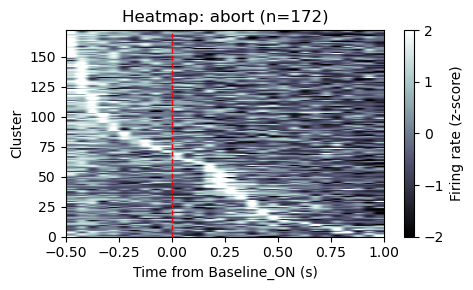

Plotted 172 clusters for abort.

Processing outcome: FA


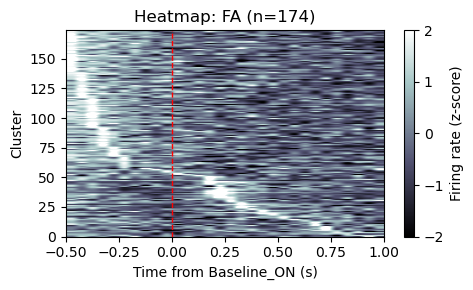

Plotted 174 clusters for FA.

Processing outcome: Hit


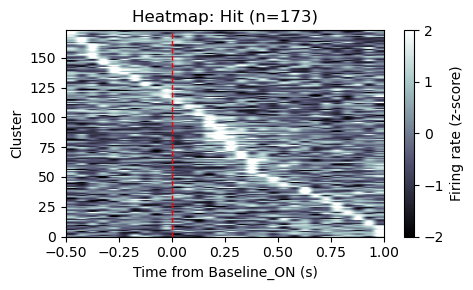

Plotted 173 clusters for Hit.

Processing outcome: Miss


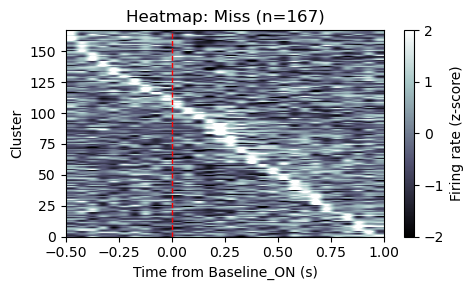

Plotted 167 clusters for Miss.


In [3]:
# Cluster Heatmap Around Baseline_ON for Each Outcome (with Motor Contamination Control)
plot_cluster_heatmap_baselineON_motor_control(session, outcomes_to_compare=['abort','FA','Hit','Miss'], min_trials_with_spikes=20, normalize=True, sort_by='peak', pre_motor_buffer=1.0)

Mean firing rate for Miss: 8.05 Hz (n=166)
Mean firing rate for FA: 10.99 Hz (n=166)
Mean firing rate for Hit: 10.43 Hz (n=166)
Mean firing rate for abort: 12.25 Hz (n=166)


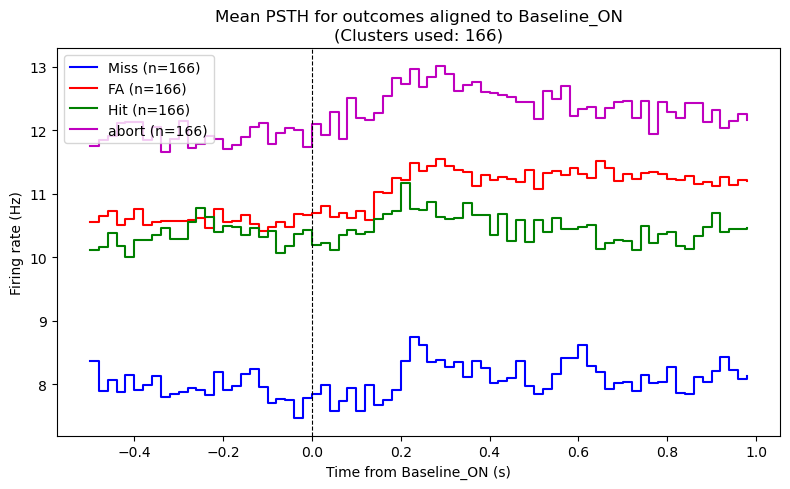

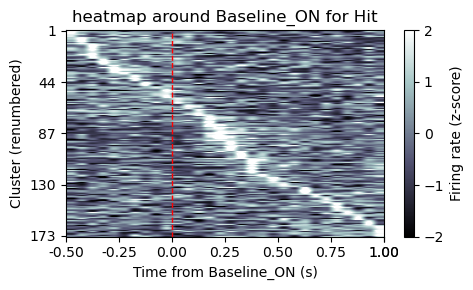

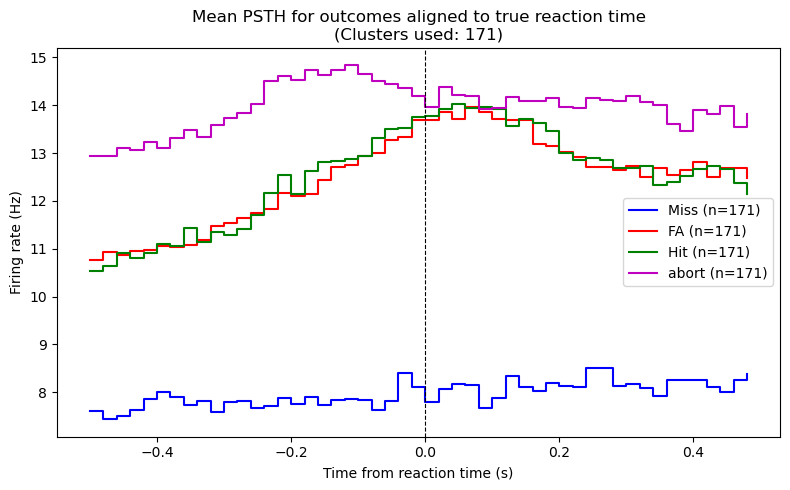

In [6]:

# Sorted PSTH/raster grid
# plot_psth_raster_grid_sorted(session, align_to='Change_ON', outcome_of_interest='Hit', clusters_per_row=10, min_trials_with_spikes=20)

# Mean PSTH comparison
plot_mean_psth_comparison(session, align_to='Baseline_ON', outcomes_to_compare=['Miss','FA', 'Hit', 'abort'], min_trials_with_spikes=20, use_same_clusters=True)

# Cluster heatmap
plot_cluster_heatmap(session, align_to='Baseline_ON', outcome_of_interest='Hit', min_trials_with_spikes=20, normalize=True)

# Plot PSTH aligned to true reaction time for each outcome
plot_psth_aligned_to_reaction_time(session, outcomes_to_compare=['Miss','FA', 'Hit', 'abort'], window=[-0.5,0.5], bin_size=0.02, min_trials_with_spikes=10, use_same_clusters=True , shift_fa_hit_ms=200.0)

# # Cluster Heatmap Around Baseline_ON for Each Outcome (with Motor Contamination Control)
# plot_cluster_heatmap_baselineON_motor_control(session, outcomes_to_compare=['abort','FA','Hit','Miss'], min_trials_with_spikes=20, normalize=True, sort_by='peak', pre_motor_buffer=1.0)


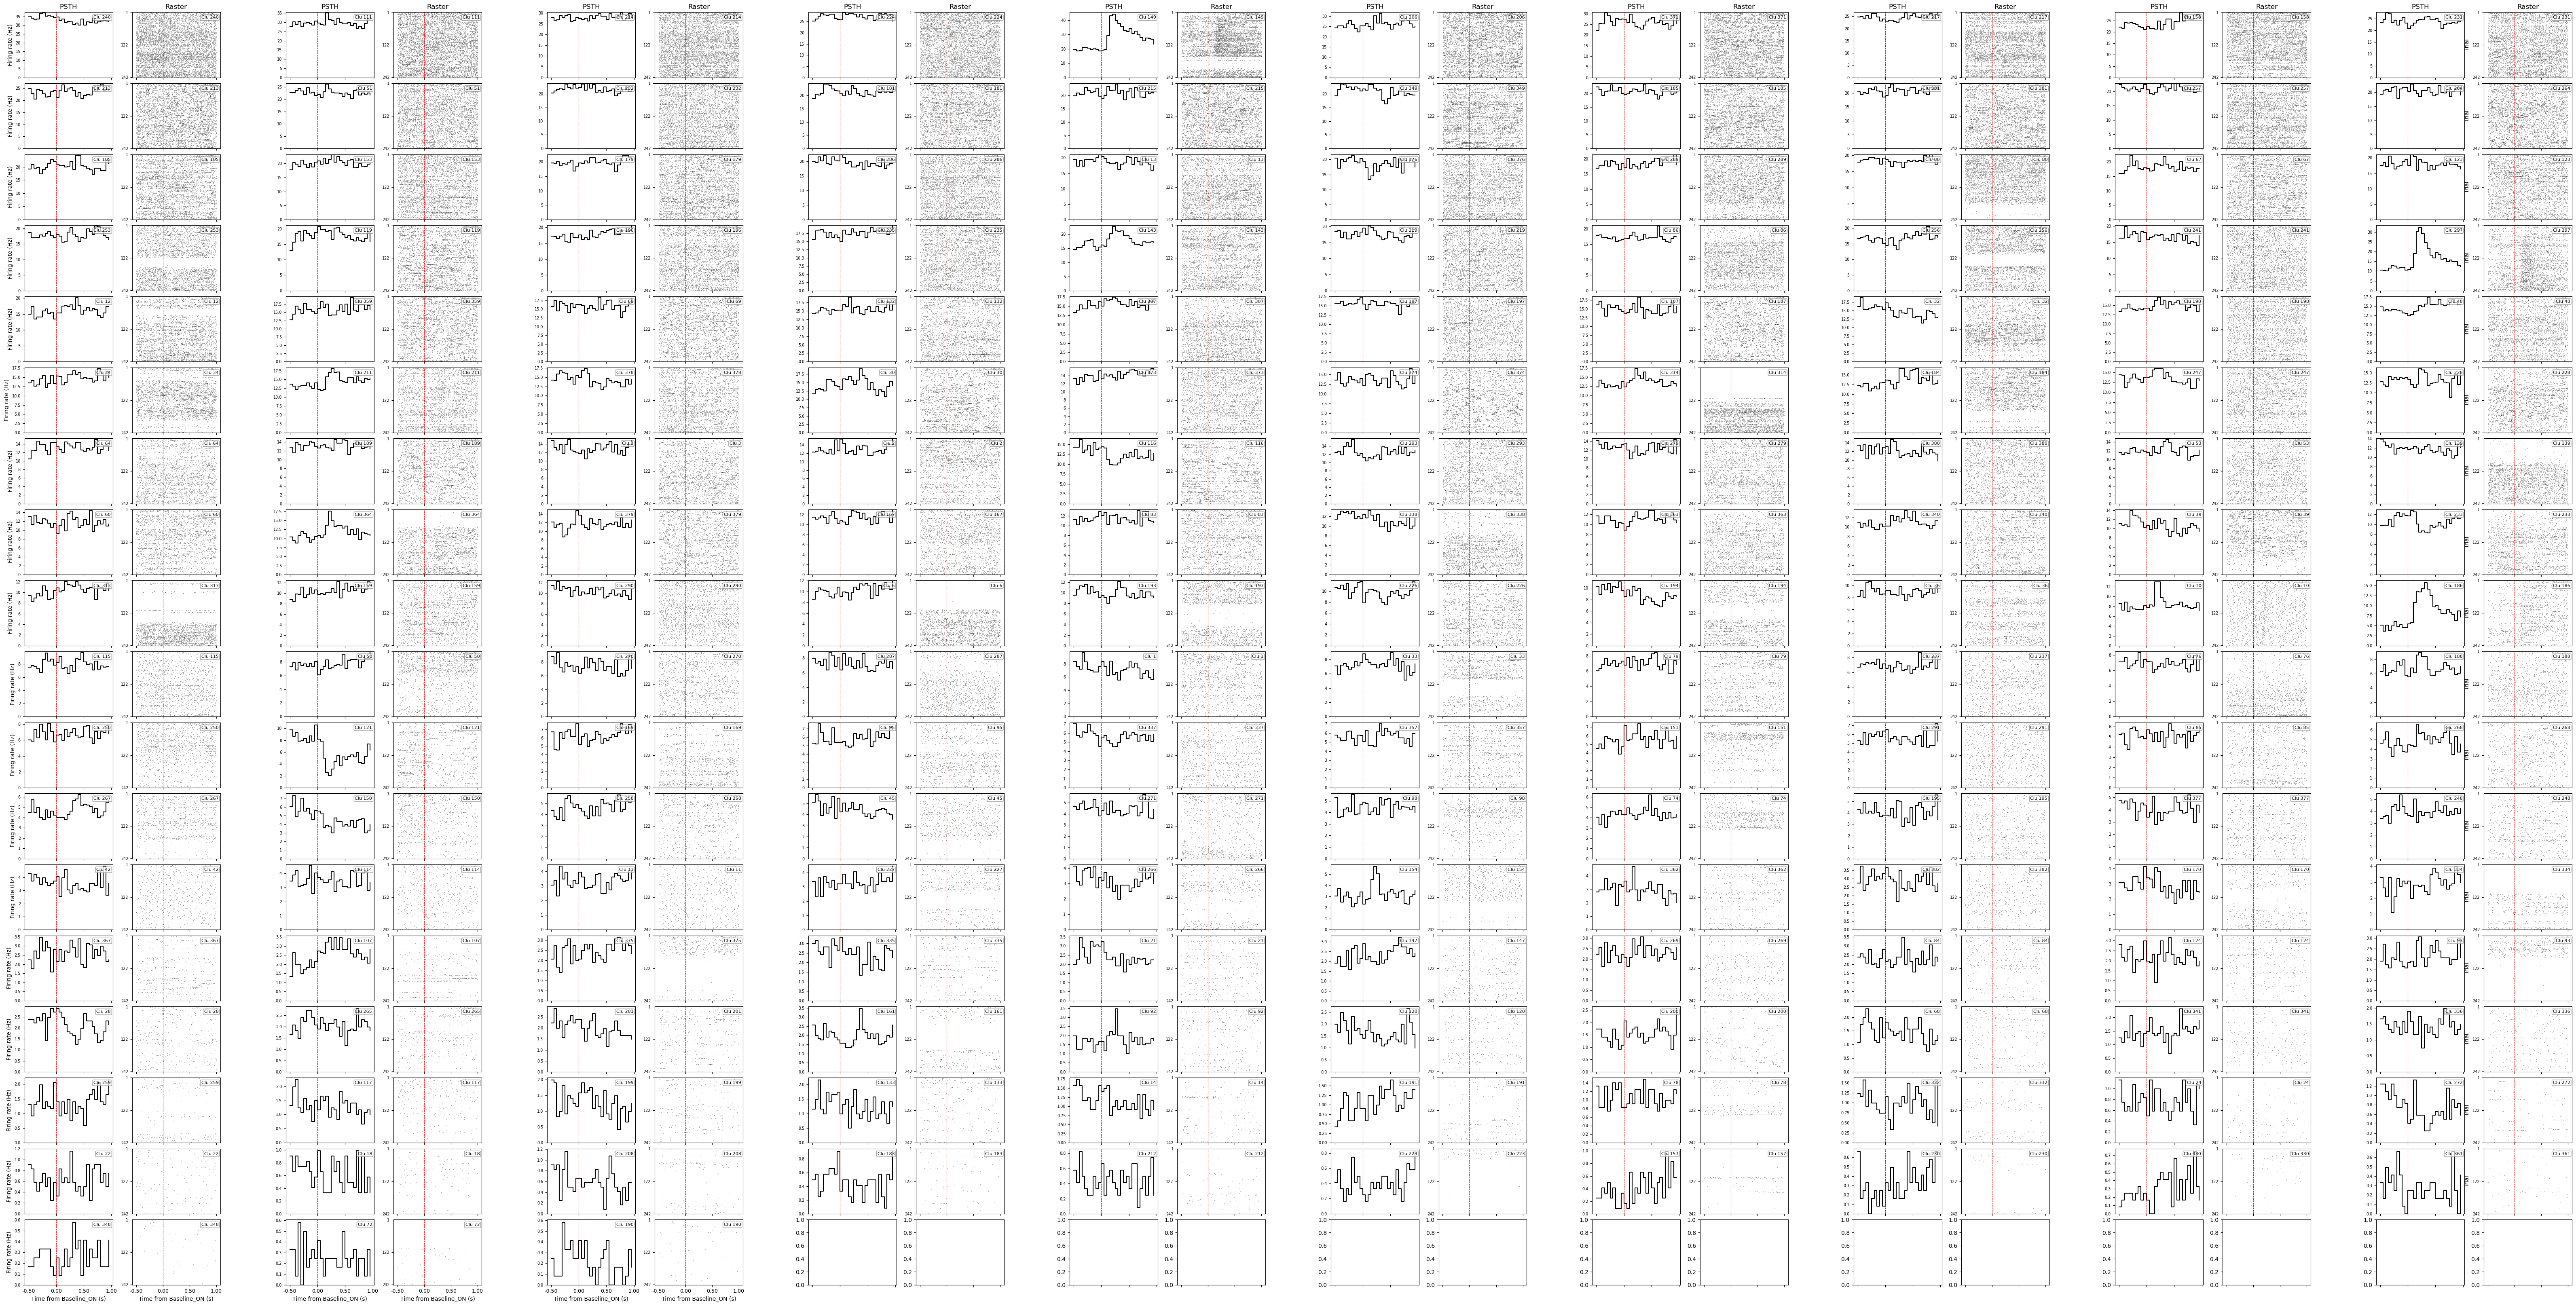

In [7]:
# Sorted PSTH/raster grid
plot_psth_raster_grid_sorted(session, align_to='Baseline_ON', outcome_of_interest='Hit', clusters_per_row=10, min_trials_with_spikes=20)



# Comparative Cluster Heatmaps Around Baseline_ON for Each Outcome (with Motor Contamination Control and Shared Axes)
This cell generates comparative heatmaps for 'abort', 'FA', 'Hit', and 'Miss' outcomes, with options for:
- Only including clusters present for all outcomes
- Shared axes for direct comparison
- Special handling for 'Hit' trials with change size 1 (probe/impulsive licks)

In [13]:
def plot_comparative_cluster_heatmaps_baselineON(
    session,
    outcomes_to_compare=['abort','FA','Hit','Miss'],
    min_trials_with_spikes=20,
    normalize=True,
    sort_by='peak',
    pre_motor_buffer=1.0,
    only_common_clusters=True,
    separate_hit_probe=True,
    save_figure=False,
    orientation='horizontal',  # 'horizontal' or 'vertical' for heatmap arrangement
    sorting_mode='reference',  # 'reference', 'average', 'independent', or 'hit_increase_decrease'
    reference_outcome='Hit'    # Only used if sorting_mode='reference'
):
    """
    Plot comparative cluster heatmaps for all outcomes with shared axes and cluster set.
    - only_common_clusters: if True, only clusters present for all outcomes are shown
    - separate_hit_probe: if True, Hit trials with change size 1 are shown separately
    - orientation: 'horizontal' (default) or 'vertical' for heatmap arrangement
    - sorting_mode: 'reference' (sort by peak in reference_outcome),
                    'average' (sort by average peak across outcomes),
                    'independent' (sort each outcome independently)
    - reference_outcome: which outcome to use for sorting if sorting_mode='reference'
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    npx_probes = session['NPX_probes']
    ni_events = session['NI_events']
    trials, outcomes = get_trials_and_outcomes(session)
    spike_times = npx_probes['st']
    cluster_ids = npx_probes['clu']
    good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
    window = [-0.5, 1.0]
    bin_size = 0.05
    bins = np.arange(window[0], window[1] + bin_size, bin_size)
    baseline_on = ni_events['Baseline_ON']
    if isinstance(baseline_on, dict) and 'rise_t' in baseline_on:
        baseline_on_times = np.array(baseline_on['rise_t']).flatten()
    else:
        baseline_on_times = np.array(baseline_on).flatten()
    # Prepare outcome trial indices
    outcome_trial_indices = {}
    for outcome in outcomes_to_compare:
        if outcome == 'Hit' and separate_hit_probe:
            hit_idx = np.where(outcomes == 'Hit')[0]
            change_sizes = np.array([trials[i].get('change_size', None) for i in hit_idx])
            probe_idx = hit_idx[change_sizes == 1]
            real_idx = hit_idx[change_sizes != 1]
            outcome_trial_indices['Hit_real'] = real_idx
            outcome_trial_indices['Hit_probe'] = probe_idx
        else:
            outcome_trial_indices[outcome] = np.where(outcomes == outcome)[0]
    # Compute PSTHs for each cluster and outcome
    all_psths_by_outcome = {}
    clusters_passing = {}
    for outcome, trial_indices in outcome_trial_indices.items():
        print(f"\nProcessing outcome: {outcome}")
        if len(trial_indices) == 0:
            print(f"No trials for outcome {outcome}.")
            all_psths_by_outcome[outcome] = {}
            clusters_passing[outcome] = set()
            continue
        if outcome in ['FA','abort']:
            rts = []
            for idx in trial_indices:
                trial = trials[idx]
                rt = trial.get('reactiontimes', {}).get(outcome, np.nan)
                rts.append(rt)
            rts = np.array(rts)
        else:
            rts = None
        all_psths = {}
        passing_clusters = set()
        for clu in good_clusters:
            spike_times_clu = spike_times[cluster_ids == clu]
            trial_starts = baseline_on_times[trial_indices]
            if outcome in ['FA','abort']:
                valid_mask = ~np.isnan(rts)
                trial_starts = trial_starts[valid_mask]
                rts_valid = rts[valid_mask]
                if len(trial_starts) == 0:
                    continue
                all_counts = []
                for t0, rt in zip(trial_starts, rts_valid):
                    aligned = spike_times_clu - t0
                    mask = (aligned >= window[0]) & (aligned <= window[1]) & (aligned <= rt - pre_motor_buffer)
                    counts, _ = np.histogram(aligned[mask], bins=bins)
                    all_counts.append(counts)
            else:
                all_counts = []
                for t0 in trial_starts:
                    aligned = spike_times_clu - t0
                    mask = (aligned >= window[0]) & (aligned <= window[1])
                    counts, _ = np.histogram(aligned[mask], bins=bins)
                    all_counts.append(counts)
            all_counts = np.array(all_counts)
            n_trials_with_spikes = np.sum(np.sum(all_counts, axis=1) > 0)
            if n_trials_with_spikes > min_trials_with_spikes:
                mean_psth = np.mean(all_counts, axis=0) / bin_size
                all_psths[clu] = mean_psth
                passing_clusters.add(clu)
        all_psths_by_outcome[outcome] = all_psths
        clusters_passing[outcome] = passing_clusters
    # Find common clusters if requested
    if only_common_clusters and len(clusters_passing) > 0:
        common_clusters = set.intersection(*[c for c in clusters_passing.values() if len(c) > 0])
        print(f"\nNumber of clusters present for all outcomes: {len(common_clusters)}")
    else:
        all_clusters = set.union(*clusters_passing.values())
        common_clusters = all_clusters
    if len(common_clusters) == 0:
        print("No common clusters found across outcomes.")
        return
    # Prepare data matrices for each outcome
    data_matrices = {}
    cluster_labels = sorted(list(common_clusters))
    # For sorting: collect peak times for each cluster in each outcome
    peak_times_by_outcome = {}
    for outcome in outcome_trial_indices.keys():
        psths = [all_psths_by_outcome[outcome][clu] if clu in all_psths_by_outcome[outcome] else np.full(len(bins)-1, np.nan) for clu in cluster_labels]
        data = np.vstack(psths)
        # Remove all-NaN rows and keep track of which clusters are dropped
        valid_rows = ~np.all(np.isnan(data), axis=1)
        if not np.all(valid_rows):
            dropped = [clu for i, clu in enumerate(cluster_labels) if not valid_rows[i]]
            if len(dropped) > 0:
                print(f"Warning: Dropped clusters with all-NaN data for outcome {outcome}: {dropped}")
            data = data[valid_rows]
            valid_cluster_labels = [clu for i, clu in enumerate(cluster_labels) if valid_rows[i]]
        else:
            valid_cluster_labels = cluster_labels
        if data.shape[0] == 0:
            print(f"No valid clusters to plot for outcome {outcome} after NaN removal.")
            data_matrices[outcome] = (np.empty((0, len(bins)-1)), [])
            peak_times_by_outcome[outcome] = np.array([])
            continue
        if normalize:
            data = (data - np.nanmean(data, axis=1, keepdims=True)) / (np.nanstd(data, axis=1, keepdims=True) + 1e-8)
            vmin, vmax = -2, 2
            cmap = 'bone'
        else:
            vmin, vmax = np.nanpercentile(data, 1), np.nanpercentile(data, 99)
            cmap = 'bone'
        # Peak times for sorting
        peak_times = np.nanargmax(data, axis=1)
        peak_times_by_outcome[outcome] = peak_times
        data_matrices[outcome] = (data, valid_cluster_labels)
    # Find intersection of valid clusters across all outcomes (after NaN removal)
    valid_cluster_sets = [set(labels) for data, labels in data_matrices.values() if len(labels) > 0]
    if len(valid_cluster_sets) == 0:
        print("No valid clusters to plot after NaN removal.")
        return
    # Ensure clusters are present in all label_to_row mappings (after NaN removal)
    # --- FIX: define final_clusters here, before using it below ---
    label_to_row_by_outcome = {}
    for outcome in data_matrices:
        _, labels = data_matrices[outcome]
        label_to_row_by_outcome[outcome] = {clu: i for i, clu in enumerate(labels)}
    label_to_row_sets = [set(label_to_row_by_outcome[o].keys()) for o in label_to_row_by_outcome]
    final_clusters = set.intersection(*valid_cluster_sets, *label_to_row_sets)
    if len(final_clusters) == 0:
        print("No clusters with valid data across all outcomes after NaN removal.")
        return
    final_cluster_labels = sorted(list(final_clusters))
    # Build a mapping from cluster label to row index in each outcome
    label_to_row_by_outcome = {}
    for outcome in data_matrices:
        _, labels = data_matrices[outcome]
        label_to_row_by_outcome[outcome] = {clu: i for i, clu in enumerate(labels) if clu in final_clusters}
    # Sorting logic
    if sorting_mode == 'reference':
        # Use peak order from reference_outcome
        ref_outcome = reference_outcome
        ref_data, ref_labels = data_matrices[ref_outcome]
        ref_label_to_row = {clu: i for i, clu in enumerate(ref_labels) if clu in final_clusters}
        ref_peak_times = peak_times_by_outcome[ref_outcome]
        ref_rows = [ref_label_to_row[clu] for clu in final_cluster_labels]
        ref_peaks = ref_peak_times[ref_rows]
        sort_idx = np.argsort(ref_peaks)
        sorted_clusters = [final_cluster_labels[i] for i in sort_idx]
        cluster_order_by_outcome = {outcome: sorted_clusters for outcome in data_matrices}
    elif sorting_mode == 'average':
        # Average peak time across all outcomes
        peak_mat = []
        for outcome in data_matrices:
            label_to_row = label_to_row_by_outcome[outcome]
            peaks = peak_times_by_outcome[outcome]
            peak_mat.append([peaks[label_to_row[clu]] for clu in final_cluster_labels])
        peak_mat = np.array(peak_mat)
        avg_peaks = np.nanmean(peak_mat, axis=0)
        sort_idx = np.argsort(avg_peaks)
        sorted_clusters = [final_cluster_labels[i] for i in sort_idx]
        cluster_order_by_outcome = {outcome: sorted_clusters for outcome in data_matrices}
    elif sorting_mode == 'independent':
        # Each outcome sorted by its own peak time
        cluster_order_by_outcome = {}
        for outcome in data_matrices:
            label_to_row = label_to_row_by_outcome[outcome]
            peaks = peak_times_by_outcome[outcome]
            rows = [label_to_row[clu] for clu in final_cluster_labels]
            outcome_peaks = peaks[rows]
            sort_idx = np.argsort(outcome_peaks)
            sorted_clusters = [final_cluster_labels[i] for i in sort_idx]
            cluster_order_by_outcome[outcome] = sorted_clusters
    elif sorting_mode == 'hit_increase_decrease':
        # Custom sorting: sort clusters by increase/decrease in 'Hit' after Baseline_ON
        ref_outcome = 'Hit_real' if separate_hit_probe and 'Hit_real' in data_matrices else 'Hit'
        ref_data, ref_labels = data_matrices[ref_outcome]
        ref_label_to_row = {clu: i for i, clu in enumerate(ref_labels) if clu in final_clusters}
        # Define pre and post Baseline_ON windows (e.g., -0.5 to 0, 0 to 0.5)
        pre_mask = (bins[:-1] >= -0.5) & (bins[:-1] < 0)
        post_mask = (bins[:-1] >= 0) & (bins[:-1] < 0.5)
        diff_vals = []
        for clu in final_cluster_labels:
            row = ref_label_to_row[clu]
            pre = np.nanmean(ref_data[row, pre_mask])
            post = np.nanmean(ref_data[row, post_mask])
            diff_vals.append(post - pre)
        sort_idx = np.argsort(diff_vals)[::-1]  # descending: increases at top
        sorted_clusters = [final_cluster_labels[i] for i in sort_idx]
        cluster_order_by_outcome = {outcome: sorted_clusters for outcome in data_matrices}
    else:
        raise ValueError(f"Unknown sorting_mode: {sorting_mode}")
    # Rebuild data matrices to only include final_clusters, in sorted order for each outcome
    for outcome in data_matrices:
        data, labels = data_matrices[outcome]
        label_to_row = {clu: i for i, clu in enumerate(labels)}
        sorted_clusters = cluster_order_by_outcome[outcome]
        rows = [label_to_row[clu] for clu in sorted_clusters if clu in label_to_row]
        data_matrices[outcome] = data[rows, :] if len(rows) > 0 else np.empty((0, len(bins)-1))
    # Plotting
    n_outcomes = len(data_matrices)
    if orientation == 'horizontal':
        fig, axes = plt.subplots(1, n_outcomes, figsize=(5*n_outcomes, min(3, len(final_cluster_labels)*0.15)), sharey=True)
    else:
        fig, axes = plt.subplots(n_outcomes, 1, figsize=(5, min(3*n_outcomes, len(final_cluster_labels)*0.15*n_outcomes)), sharex=True)
    if n_outcomes == 1:
        axes = [axes]
    for i, (outcome, data) in enumerate(data_matrices.items()):
        ax = axes[i] if orientation == 'horizontal' else axes[i]
        im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[bins[0], bins[-1], 0, len(final_cluster_labels)])
        ax.axvline(0, color='red', linestyle='--', linewidth=1)
        if orientation == 'horizontal':
            ax.set_title(outcome)
            if i == 0:
                ax.set_ylabel('Cluster (sorted)')
        else:
            ax.set_ylabel(outcome)
            if i == n_outcomes-1:
                ax.set_xlabel('Time from Baseline_ON (s)')
    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Firing rate (z-score)' if normalize else 'Firing rate (Hz)')
    plt.tight_layout()
    if save_figure:
        output_dir = 'png_output'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'BaselineON_comparative_heatmaps.png'), dpi=150)
        plt.close()
    else:
        plt.show()
    print(f"Plotted comparative heatmaps for outcomes: {list(data_matrices.keys())}")


Processing outcome: abort

Processing outcome: FA

Processing outcome: FA

Processing outcome: Hit_real

Processing outcome: Hit_real

Processing outcome: Hit_probe
No trials for outcome Hit_probe.

Processing outcome: Miss

Processing outcome: Hit_probe
No trials for outcome Hit_probe.

Processing outcome: Miss

Number of clusters present for all outcomes: 166
No valid clusters to plot for outcome Hit_probe after NaN removal.

Number of clusters present for all outcomes: 166
No valid clusters to plot for outcome Hit_probe after NaN removal.


C:\Users\Ben\AppData\Local\Temp\ipykernel_19832\251287613.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


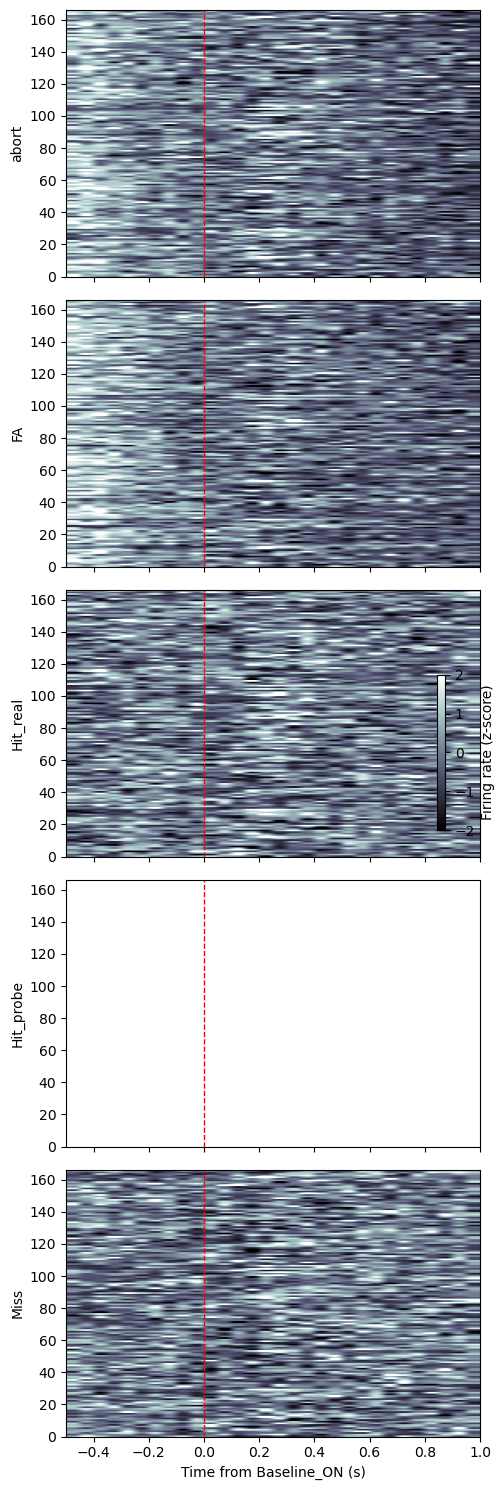

Plotted comparative heatmaps for outcomes: ['abort', 'FA', 'Hit_real', 'Hit_probe', 'Miss']


In [11]:

# Comparative Cluster Heatmaps Around Baseline_ON for Each Outcome (with Motor Contamination Control and Shared Axes)
plot_comparative_cluster_heatmaps_baselineON(
    session,
    outcomes_to_compare=['abort','FA','Hit','Miss'],
    min_trials_with_spikes=20,
    normalize=True,
    sort_by='peak',
    pre_motor_buffer=1.0,
    only_common_clusters=True,
    separate_hit_probe=True,
    orientation='vertical'
)

# Cluster Sorting Options for Comparative Heatmaps
This notebook now supports flexible cluster sorting for comparative heatmaps:

- **Reference Outcome Sorting**: Sort all clusters by their peak firing time in a user-specified outcome (e.g., 'Hit').
- **Average Peak Sorting**: Sort clusters by the average peak time across all selected outcomes.
- **Independent Sorting**: Sort clusters independently for each outcome by their own peak time (row order may differ between outcomes).

Use the `sorting_mode` argument in `plot_comparative_cluster_heatmaps_baselineON`:
- `'reference'`: Use `reference_outcome` to specify which outcome's peak order to use for all outcomes.
- `'average'`: Sort by average peak time across all outcomes.
- `'independent'`: Sort each outcome's clusters by their own peak time.

In [ ]:
# Example usage for all three sorting modes:

# 1. Reference outcome sorting (e.g., sort all by 'Hit')
plot_comparative_cluster_heatmaps_baselineON(
    session,
    outcomes_to_compare=['abort','FA','Hit','Miss'],
    min_trials_with_spikes=20,
    normalize=True,
    sort_by='peak',
    pre_motor_buffer=1.0,
    only_common_clusters=True,
    separate_hit_probe=True,
    orientation='vertical',
    sorting_mode='reference',
    reference_outcome='Hit_real'
)

# 2. Average peak sorting
plot_comparative_cluster_heatmaps_baselineON(
    session,
    outcomes_to_compare=['abort','FA','Hit','Miss'],
    min_trials_with_spikes=20,
    normalize=True,
    sort_by='peak',
    pre_motor_buffer=1.0,
    only_common_clusters=True,
    separate_hit_probe=True,
    orientation='vertical',
    sorting_mode='average'
)

# 3. Independent sorting for each outcome
plot_comparative_cluster_heatmaps_baselineON(
    session,
    outcomes_to_compare=['abort','FA','Hit','Miss'],
    min_trials_with_spikes=20,
    normalize=True,
    sort_by='peak',
    pre_motor_buffer=1.0,
    only_common_clusters=True,
    separate_hit_probe=True,
    orientation='vertical',
    sorting_mode='independent'
)



Processing outcome: abort

Processing outcome: FA

Processing outcome: FA

Processing outcome: Hit_real

Processing outcome: Hit_real

Processing outcome: Hit_probe
No trials for outcome Hit_probe.

Processing outcome: Miss

Processing outcome: Hit_probe
No trials for outcome Hit_probe.

Processing outcome: Miss

Number of clusters present for all outcomes: 166
No valid clusters to plot for outcome Hit_probe after NaN removal.

Number of clusters present for all outcomes: 166
No valid clusters to plot for outcome Hit_probe after NaN removal.


NameError: free variable 'final_clusters' referenced before assignment in enclosing scope

In [11]:

# 4. New: Sorting by increase/decrease after Baseline_ON for 'Hit' trials
plot_comparative_cluster_heatmaps_baselineON(
    session,
    outcomes_to_compare=['abort','FA','Hit','Miss'],
    min_trials_with_spikes=20,
    normalize=True,
    sort_by='peak',
    pre_motor_buffer=1.0,
    only_common_clusters=True,
    separate_hit_probe=True,
    orientation='vertical',
    sorting_mode='hit_increase_decrease'
)


Processing outcome: abort

Processing outcome: FA

Processing outcome: FA

Processing outcome: Hit_real

Processing outcome: Hit_real

Processing outcome: Hit_probe
No trials for outcome Hit_probe.

Processing outcome: Miss

Processing outcome: Hit_probe
No trials for outcome Hit_probe.

Processing outcome: Miss

Number of clusters present for all outcomes: 166
No valid clusters to plot for outcome Hit_probe after NaN removal.
No clusters with valid data across all outcomes after NaN removal.

Number of clusters present for all outcomes: 166
No valid clusters to plot for outcome Hit_probe after NaN removal.
No clusters with valid data across all outcomes after NaN removal.
